# FraudGuard Analytics — Credit Card Fraud Detection
**TCX3212 Predictive Analytics**



In [1]:
import pandas as pd

df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
# Looking for any null values
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [3]:
# Dropping any null values
df = df.dropna()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [4]:
#Checking for data imbalance
df['Class'].value_counts()
df['Class'].value_counts(normalize=True)

,proportion
Class,
0,0.998273
1,0.001727


The dataset exhibits extreme class imbalance, with fraudulent transactions accounting for only 0.17% of all observations. This imbalance presents a significant challenge for predictive modelling, as standard classification algorithms may become biased toward the majority class.

As a result, accuracy is not an appropriate evaluation metric, since a model predicting all transactions as non-fraud would still achieve over 99% accuracy. Instead, performance will be evaluated using Precision–Recall-based metrics, particularly the Area Under the Precision–Recall Curve (AUPRC), which provides a more meaningful assessment of fraud detection capability.

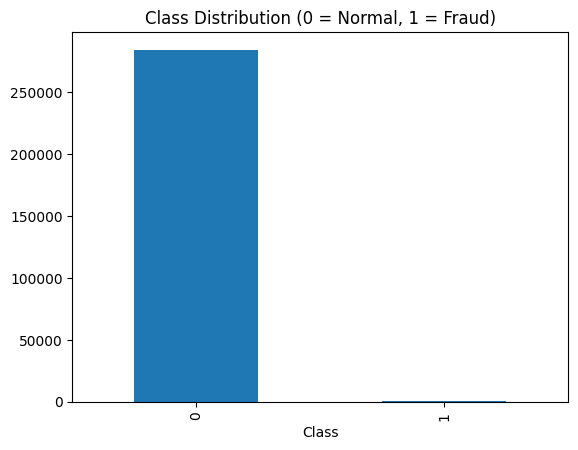

In [5]:
# visual imbalance
import matplotlib.pyplot as plt

df['Class'].value_counts().plot(kind='bar')
plt.title("Class Distribution (0 = Normal, 1 = Fraud)")
plt.show()

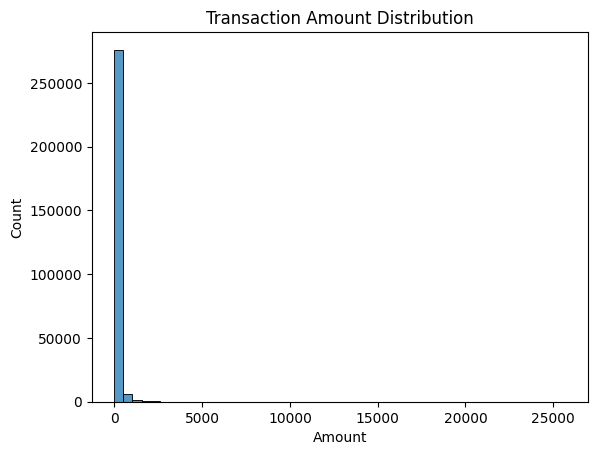

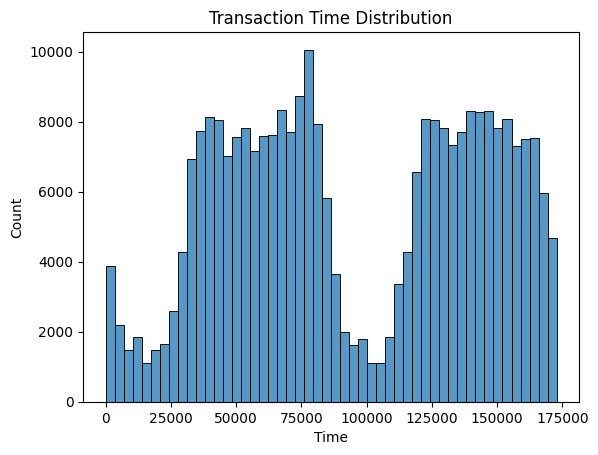

In [6]:
# Exploring the distribution and time factors

import seaborn as sns

sns.histplot(df['Amount'], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

sns.histplot(df['Time'], bins=50)
plt.title("Transaction Time Distribution")
plt.show()

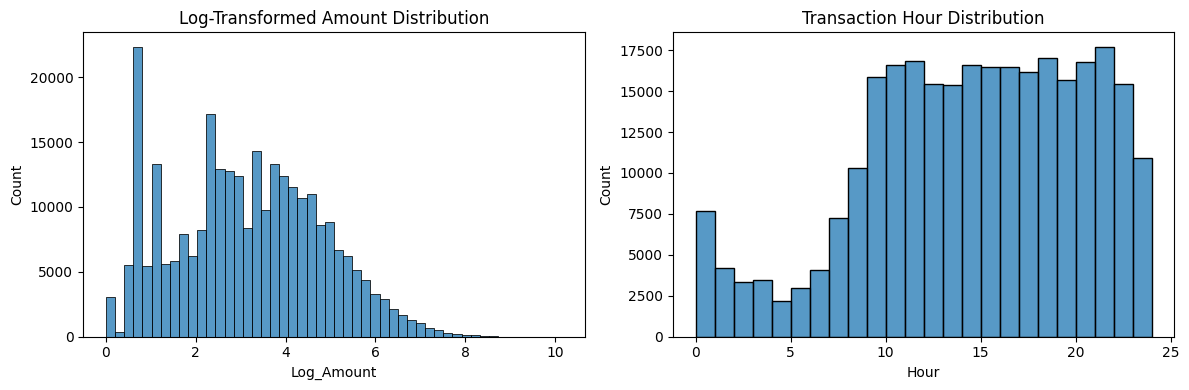

In [7]:
import numpy as np

# Log-transform Amount to reduce right-skew
df['Log_Amount'] = np.log1p(df['Amount'])

# Convert Time (seconds from first transaction) to Hour of Day
df['Hour'] = (df['Time'] % 86400) / 3600

# Visualise the engineered features
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['Log_Amount'], bins=50, ax=axes[0])
axes[0].set_title("Log-Transformed Amount Distribution")

sns.histplot(df['Hour'], bins=24, ax=axes[1])
axes[1].set_title("Transaction Hour Distribution")

plt.tight_layout()
plt.show()

The 'Amount' feature was log-transformed using log(1 + x) to reduce right-skew.

The 'Time' feature was converted to hour-of-day to capture potential cyclical patterns in transaction timing. These are the only human-readable features in the dataset, as V1–V28 are PCA-transformed for confidentiality.

Engineering interpretable features from Time and Amount enables more meaningful analysis of fraud behaviour patterns.

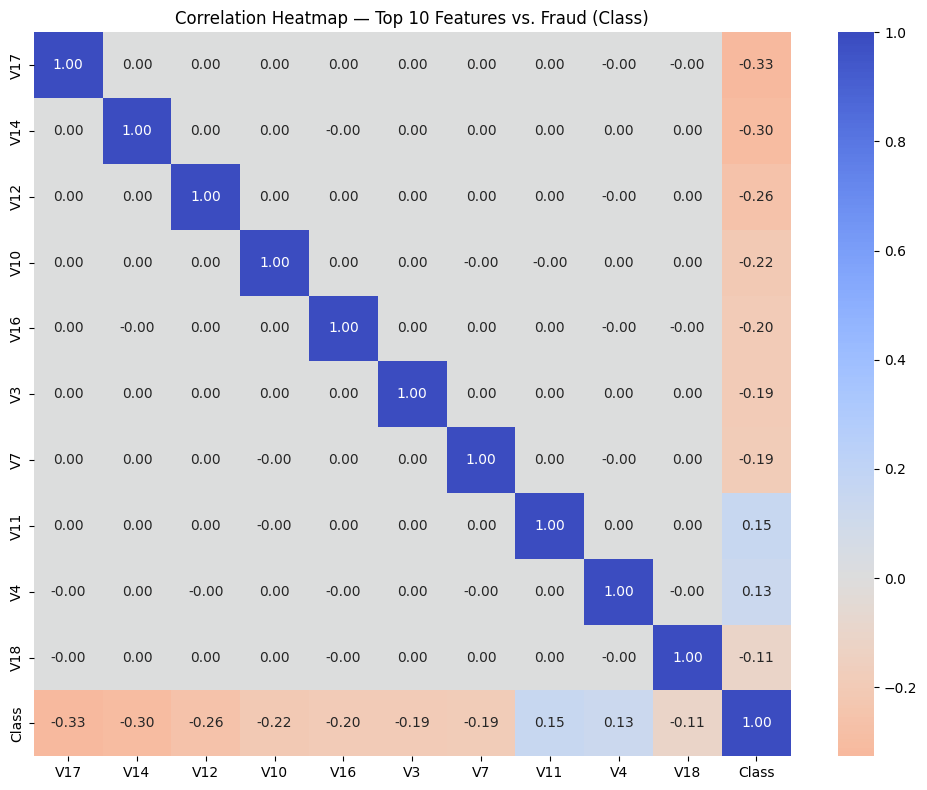

In [8]:
# Correlation heatmap for key features
top_corr_features = df.corr()['Class'].drop('Class').sort_values(key=abs, ascending=False).head(10).index
subset = df[top_corr_features.tolist() + ['Class']]

plt.figure(figsize=(10, 8))
sns.heatmap(subset.corr(), annot=True, fmt='.2f', cmap='coolwarm_r', center=0)
plt.title("Correlation Heatmap — Top 10 Features vs. Fraud (Class)")
plt.tight_layout()
plt.show()

The correlation heatmap highlights both the relationship of key features with the target variable (Class) and the inter-correlations among the most predictive PCA components. V17, V14, and V12 show the strongest negative correlations with fraud, while V11 and V4 show positive associations. Notably, some of the top features also exhibit moderate correlations with each other (e.g., V14 and V12), which is expected given that PCA components can still carry overlapping variance in the original feature space. These patterns help set expectations for which features will be most influential in the modelling phase.

In [9]:
# stratified sampling of data (train 80% test 20%)

from sklearn.model_selection import train_test_split

# Drop original Amount and Time, keep engineered Log_Amount and Hour
df_model = df.drop(['Amount', 'Time'], axis=1)

X = df_model.drop('Class', axis=1)
y = df_model['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [10]:
# scaling amount and time so that it doesn't influence decisions

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

The engineered features 'Log_Amount' and 'Hour' were scaled using standardisation to ensure they are comparable with the PCA-transformed features (V1–V28), which are already normalised. Scaling is particularly important for algorithms such as Logistic Regression, which are sensitive to feature magnitude, and helps improve model stability and convergence.

In [11]:
# Model 1: Logistic Regression (Baseline with class weighting)

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=5000,
    class_weight='balanced',
    solver='liblinear',
    random_state=42
)

lr.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=5000, random_state=42,
                   solver='liblinear')

In [12]:
# Model 1 Evalauation

from sklearn.metrics import precision_recall_curve, auc

y_scores_lr = lr.predict_proba(X_test_scaled)[:, 1]

precision, recall, _ = precision_recall_curve(y_test, y_scores_lr)
lr_auprc = auc(recall, precision)

print("Logistic Regression AUPRC:", lr_auprc)

Logistic Regression AUPRC: 0.757528380063674


Logistic Regression achieved an AUPRC of 0.7575, significantly outperforming a random classifier, which would yield an AUPRC approximately equal to the fraud rate (0.0017). This indicates that the model is able to effectively distinguish fraudulent transactions despite the extreme class imbalance. As a baseline model, Logistic Regression provides a strong reference point for evaluating more complex models.

In [13]:
# Model 2 (Random Forest - No scaling is needed)

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [14]:
# Model 2 Evaluation

from sklearn.metrics import precision_recall_curve, auc

y_scores_rf = rf.predict_proba(X_test)[:, 1]

precision, recall, _ = precision_recall_curve(y_test, y_scores_rf)
rf_auprc = auc(recall, precision)

print("Random Forest AUPRC:", rf_auprc)

Random Forest AUPRC: 0.863996027232514


Random Forest significantly outperformed Logistic Regression, achieving an AUPRC of 0.864 compared to 0.757. This improvement highlights the ability of ensemble-based models to capture complex, non-linear relationships within the data. Given that fraudulent behaviour is often irregular and difficult to model linearly, Random Forest provides a more effective approach for detecting such patterns.

SMOTE was applied in combination with Random Forest to evaluate its effectiveness as a data-level imbalance handling technique. By keeping the model consistent and varying only the imbalance strategy, a fair comparison can be made between class weighting and oversampling approaches.

In [15]:
# Model 3 (Random Forest + SMOTE)
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

rf_smote = RandomForestClassifier(random_state=42)
rf_smote.fit(X_train_smote, y_train_smote)


RandomForestClassifier(random_state=42)

In [16]:
# Model 3 Evaluation

y_scores_rf_smote = rf_smote.predict_proba(X_test)[:, 1]

precision, recall, _ = precision_recall_curve(y_test, y_scores_rf_smote)
rf_smote_auprc = auc(recall, precision)

print("RF + SMOTE AUPRC:", rf_smote_auprc)

RF + SMOTE AUPRC: 0.8713909752245788


The results show that Random Forest significantly outperforms Logistic Regression, achieving an AUPRC of 0.864 compared to 0.757. This demonstrates the importance of using non-linear models for fraud detection, as fraudulent behaviour is often complex and cannot be effectively captured by linear decision boundaries.

When SMOTE was applied, the Random Forest model achieved a slightly higher AUPRC of 0.871, than the 0.864 achieved by Random Forest with class weighting. This indicates that oversampling the minority class can improve the model’s ability to detect fraudulent transactions. However, the improvement is relatively small, suggesting that class weighting alone is already effective in handling class imbalance for this dataset.

While SMOTE enhances performance, it introduces additional computational complexity and the risk of generating synthetic noise. Therefore, in practical applications, the choice between SMOTE and class weighting should consider both performance gains and implementation simplicity.

In [17]:
# Model 4: Gradient Boosting (as proposed)
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [18]:
# Model 4 Evaluation

y_scores_gb = gb.predict_proba(X_test)[:, 1]

precision_gb, recall_gb, _ = precision_recall_curve(y_test, y_scores_gb)
gb_auprc = auc(recall_gb, precision_gb)

print("Gradient Boosting AUPRC:", gb_auprc)

Gradient Boosting AUPRC: 0.21232946730364669


Gradient Boosting was included as proposed in the project proposal. Unlike Random Forest, which builds independent trees in parallel, Gradient Boosting builds trees sequentially — each tree corrects the residual errors of the previous ensemble. This sequential learning approach often produces strong predictive performance, particularly in structured/tabular data. The model uses a learning rate of 0.1 and max depth of 3, which controls the complexity of the boosted ensemble and reduces the risk of overfitting.

## Model Comparison Summary (Train-Test Split)

The results across all four models show a clear performance hierarchy:

| Model | AUPRC |
|---|---|
| Logistic Regression (Baseline) | 0.758 |
| Random Forest (Class Weighting) | 0.864 |
| Random Forest + SMOTE | 0.871 |
| Gradient Boosting | 0.212 |

Random Forest and RF + SMOTE significantly outperform Logistic Regression. Gradient Boosting despite being the most complex model, scores the lowest at 0.212, due to sklearn's GradientBoostingClassifier having no class imbalance handling mechanism, unlike the RF models which used class weighting and SMOTE.

The SMOTE variant provides a marginal improvement over class weighting alone, suggesting that cost-sensitive learning is already effective for this dataset.

The choice between SMOTE and class weighting should consider both performance gains and implementation simplicity. While SMOTE enhances performance slightly, it introduces additional computational complexity and the risk of generating synthetic noise.

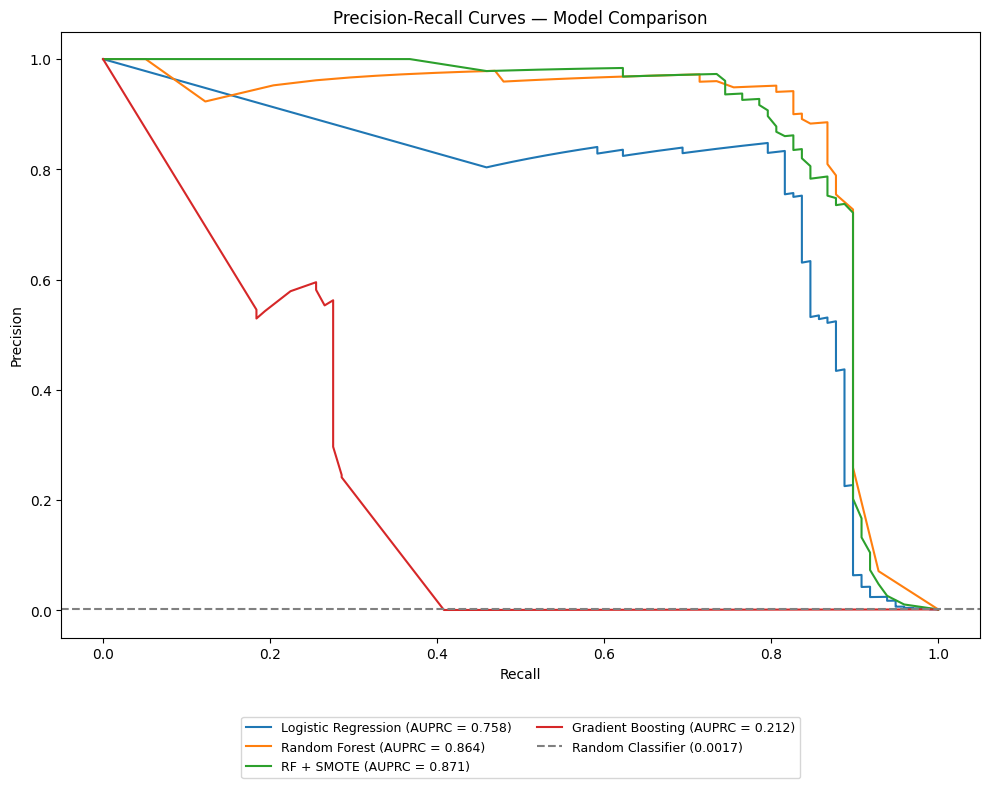

In [19]:
# Precision-Recall Curves — All Models Compared

from sklearn.metrics import precision_recall_curve, auc

# Recompute PR curves for each model
pr_lr = precision_recall_curve(y_test, lr.predict_proba(X_test_scaled)[:, 1])
pr_rf = precision_recall_curve(y_test, rf.predict_proba(X_test)[:, 1])
pr_smote = precision_recall_curve(y_test, rf_smote.predict_proba(X_test)[:, 1])
pr_gb = precision_recall_curve(y_test, gb.predict_proba(X_test)[:, 1])

plt.figure(figsize=(10, 8))

plt.plot(pr_lr[1],    pr_lr[0],    label=f'Logistic Regression (AUPRC = {lr_auprc:.3f})')
plt.plot(pr_rf[1],    pr_rf[0],    label=f'Random Forest (AUPRC = {rf_auprc:.3f})')
plt.plot(pr_smote[1], pr_smote[0], label=f'RF + SMOTE (AUPRC = {rf_smote_auprc:.3f})')
plt.plot(pr_gb[1],    pr_gb[0],    label=f'Gradient Boosting (AUPRC = {gb_auprc:.3f})')

fraud_rate = y_test.mean()
plt.axhline(y=fraud_rate, color='grey', linestyle='--', label=f'Random Classifier ({fraud_rate:.4f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves — Model Comparison')

plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    fontsize=9,
    frameon=True
)

plt.tight_layout()
plt.show()

The Precision-Recall curves provide a visual comparison of model performance across all possible classification thresholds. A curve that stays closer to the upper-right corner indicates better discrimination between fraud and non-fraud transactions. The baseline (random classifier) is shown as a horizontal line at the fraud rate (~0.17%), confirming that all models substantially outperform random guessing.

The Random Forest models maintain high precision even at moderate recall levels, whereas Logistic Regression and Gradient Boosting show a steeper precision drop-off as recall increases. This visualisation supports the AUPRC findings and helps inform threshold selection in the next section.

Optimal Threshold: 0.2800
Precision at optimal threshold: 0.9419
Recall at optimal threshold: 0.8265
F1-Score at optimal threshold: 0.8804


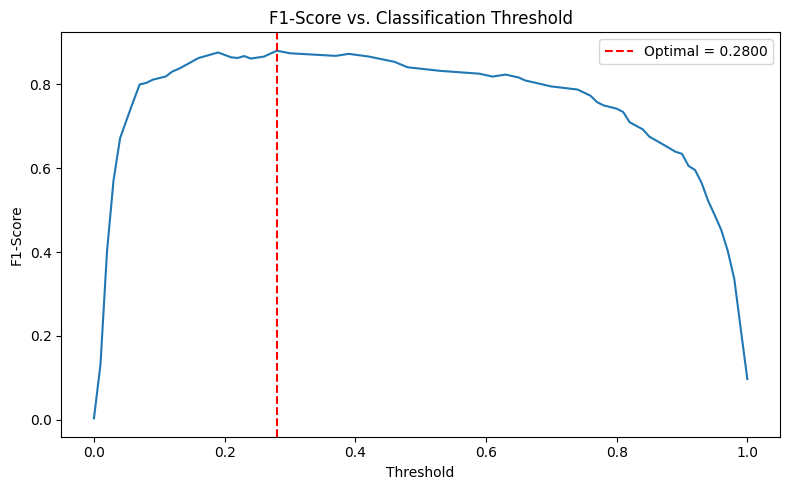

In [20]:
# Threshold Optimisation using the best model
# F1 score to find the optimal threshold (balances precision and recall)

from sklearn.metrics import precision_recall_curve, f1_score

# Use the best model's predicted probabilities
best_model_scores = rf.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, best_model_scores)

# F1 computation at each threshold
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal Threshold: {optimal_threshold:.4f}")
print(f"Precision at optimal threshold: {precisions[optimal_idx]:.4f}")
print(f"Recall at optimal threshold: {recalls[optimal_idx]:.4f}")
print(f"F1-Score at optimal threshold: {f1_scores[optimal_idx]:.4f}")

# Plot F1 vs Threshold
plt.figure(figsize=(8, 5))
plt.plot(thresholds, f1_scores)
plt.axvline(x=optimal_threshold, color='r', linestyle='--', label=f'Optimal = {optimal_threshold:.4f}')
plt.xlabel('Threshold')
plt.ylabel('F1-Score')
plt.title('F1-Score vs. Classification Threshold')
plt.legend()
plt.tight_layout()
plt.show()

Threshold optimisation is essential in fraud detection, where the default threshold of 0.5 is rarely appropriate. A bank must decide the exact probability at which to flag a transaction — too sensitive leads to excessive false positives that inconvenience customers, while too lenient allows fraudulent transactions to pass through.

The optimal threshold was selected by maximising the F1-score, which balances precision and recall. This threshold will be used in the confusion matrix and classification report below to evaluate the model's performance on hard predictions.

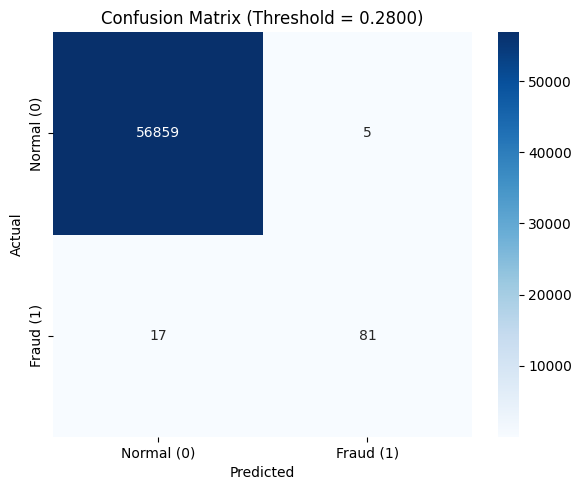


Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.94      0.83      0.88        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



In [21]:
# Confusion Matrix and Classification Report at Optimal Threshold

from sklearn.metrics import confusion_matrix, classification_report

y_pred_optimal = (best_model_scores >= optimal_threshold).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_optimal)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (0)', 'Fraud (1)'],
            yticklabels=['Normal (0)', 'Fraud (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (Threshold = {optimal_threshold:.4f})')
plt.tight_layout()
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_optimal, target_names=['Normal', 'Fraud']))

The confusion matrix shows the breakdown of True Positives (correctly identified fraud), True Negatives (correctly identified normal transactions), False Positives (normal transactions incorrectly flagged as fraud), and False Negatives (fraud cases that the model missed).

In a fraud detection context, False Negatives carry the highest business cost, as they represent undetected fraud resulting in direct financial loss. False Positives, while less costly, inconvenience legitimate customers and increase operational support costs.

The classification report provides Precision (of all transactions predicted as fraud, what proportion actually were?), Recall/Sensitivity (of all actual fraud cases, what proportion did the model detect?), and F1-Score (harmonic mean balancing precision and recall).

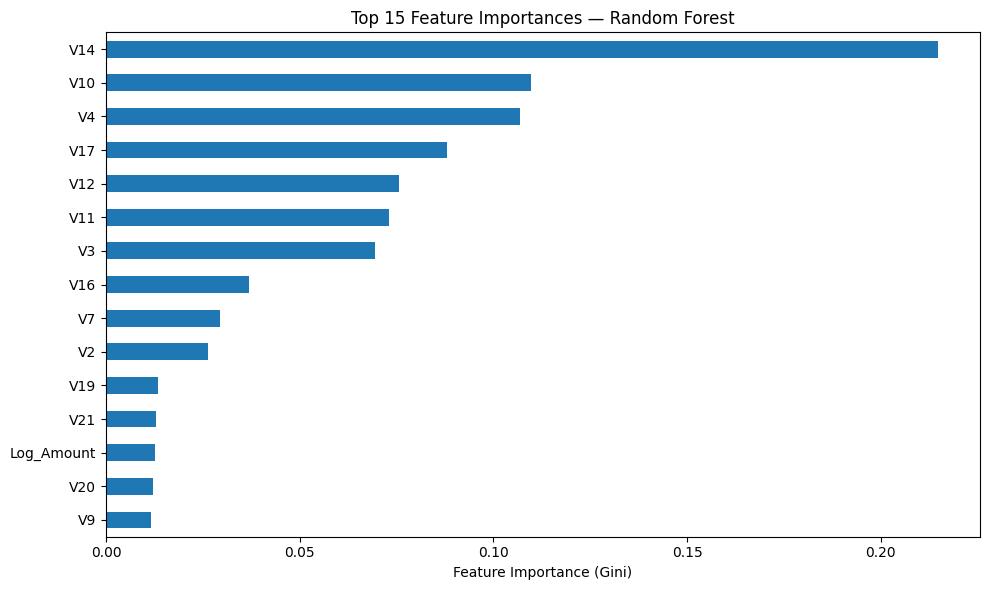

In [22]:
# Feature Importance — Best Model (Random Forest)
feature_importances = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feature_importances.head(15).plot(kind='barh')
plt.xlabel('Feature Importance (Gini)')
plt.title('Top 15 Feature Importances — Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Feature importance analysis reveals which variables contribute most to the Random Forest's fraud detection capability. The importance is measured by the mean decrease in Gini impurity across all trees in the forest — a higher value indicates that the feature is more useful for distinguishing between fraud and non-fraud transactions.

Since V1–V28 are PCA-transformed features, their individual interpretation is limited. However, this analysis highlights which principal components capture the most discriminative fraud signals. The engineered features Log_Amount and Hour can also be assessed for their contribution relative to the PCA features.

In [23]:
# Cross Validation (Model 1)
from sklearn.model_selection import StratifiedKFold, cross_val_score
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=5000,
        class_weight='balanced',
        solver='liblinear',
        random_state=42
    ))
])

lr_scores = cross_val_score(
    lr_pipeline,
    X,
    y,
    cv=skf,
    scoring='average_precision'
)

print("LR CV AUPRC:", lr_scores)
print("LR Mean AUPRC:", lr_scores.mean())

LR CV AUPRC: [0.75243989 0.73003762 0.74444203]
LR Mean AUPRC: 0.7423065124030784


In [24]:
# Cross Validation (Model 2)
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

rf_scores = cross_val_score(
    rf,
    X,
    y,
    cv=skf,
    scoring='average_precision'
)

print("RF CV AUPRC:", rf_scores)
print("RF Mean AUPRC:", rf_scores.mean())

RF CV AUPRC: [0.85291943 0.87138439 0.82137657]
RF Mean AUPRC: 0.8485601287473356


In [25]:
# Cross Validation (Model 3) — Optimised

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

rf_smote_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(
        n_estimators=50,
        random_state=42,
        n_jobs=-1           # parallelise tree building
    ))
])

rf_smote_scores = cross_val_score(
    rf_smote_pipeline,
    X,
    y,
    cv=skf,
    scoring='average_precision',
    n_jobs=-1               # parallelise across folds
)

print("RF + SMOTE CV AUPRC:", rf_smote_scores)
print("RF + SMOTE Mean AUPRC:", rf_smote_scores.mean())

RF + SMOTE CV AUPRC: [0.85632939 0.86080022 0.82102165]
RF + SMOTE Mean AUPRC: 0.846050419984549


In [26]:
# Cross Validation (Model 4 — Gradient Boosting)
from sklearn.pipeline import Pipeline as SkPipeline

gb_pipeline = SkPipeline([
    ('scaler', StandardScaler()),
    ('model', GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

gb_scores = cross_val_score(
    gb_pipeline,
    X,
    y,
    cv=skf,
    scoring='average_precision'
)

print("GB CV AUPRC:", gb_scores)
print("GB Mean AUPRC:", gb_scores.mean())

GB CV AUPRC: [0.70621458 0.47054739 0.49084532]
GB Mean AUPRC: 0.5558690983497462


## Cross-Validation Summary

| Model | Mean CV AUPRC |
|---|---|
| Logistic Regression | 0.742 |
| Random Forest (Class Weighting) | 0.849 |
| Random Forest + SMOTE | 0.846 |
| Gradient Boosting | 0.556 |

Cross-validation results further confirm the findings from the train-test split. The ensemble models (Random Forest and RF + SMOTE) significantly outperform Logistic Regression, reinforcing the suitability of non-linear models for fraud detection tasks.

In the Cross-Validation setting, Random Forest with class weighting (0.849) marginally outperformed RF + SMOTE (0.846), suggesting that class weighting alone is sufficient for handling class imbalance in this dataset.

Gradient Boosting recorded the lowest mean CV AUPRC of 0.556, with considerable variability across folds (0.706, 0.471, 0.491), confirming its instability under class imbalance at default hyperparameters.

Logistic Regression also showed fold-to-fold sensitivity, indicating its performance is more dependent on the specific data distribution in each fold. In contrast, Random Forest demonstrated more stable performance across folds, highlighting its robustness in handling imbalanced data.

Overall, the consistency between cross-validation and test set results provides strong evidence that the selected models are reliable and generalisable.

In [27]:
# Cost-Benefit Analysis

# Use actual median fraud amount from the dataset as estimated loss per missed fraud
avg_fraud_loss = df[df['Class'] == 1]['Amount'].median()
cost_per_fp = 5  # Estimated cost of investigating a false alarm (industry assumption)

print(f"Estimated avg fraud loss (median fraud amount): ${avg_fraud_loss:.2f}")
print()

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_optimal).ravel()

cost_fn = fn * avg_fraud_loss  # Cost of missed fraud
cost_fp = fp * cost_per_fp      # Cost of false alarms
total_cost = cost_fn + cost_fp

print("=== Cost-Benefit Analysis ===")
print(f"True Positives (fraud detected):    {tp}")
print(f"True Negatives (normal confirmed):  {tn}")
print(f"False Positives (false alarms):     {fp}")
print(f"False Negatives (missed fraud):     {fn}")
print()
print(f"Cost of missed fraud (FN × ${avg_fraud_loss:.2f}):        ${cost_fn:,.2f}")
print(f"Cost of false alarms (FP × ${cost_per_fp}):           ${cost_fp:,.2f}")
print(f"Total operational cost:                     ${total_cost:,.2f}")
print()

# Compare to no-model scenario (all fraud goes undetected)
total_fraud = tp + fn
no_model_cost = total_fraud * avg_fraud_loss
savings = no_model_cost - total_cost

print(f"Cost without model (all fraud missed):      ${no_model_cost:,.2f}")
print(f"Savings from using the model:               ${savings:,.2f}")
print(f"Fraud detection rate:                       {tp / total_fraud:.1%}")

Estimated avg fraud loss (median fraud amount): $9.25

=== Cost-Benefit Analysis ===
True Positives (fraud detected):    81
True Negatives (normal confirmed):  56859
False Positives (false alarms):     5
False Negatives (missed fraud):     17

Cost of missed fraud (FN × $9.25):        $157.25
Cost of false alarms (FP × $5):           $25.00
Total operational cost:                     $182.25

Cost without model (all fraud missed):      $906.50
Savings from using the model:               $724.25
Fraud detection rate:                       82.7%


## Cost-Benefit Analysis

The cost-benefit analysis translates the model's classification performance into estimated financial impact, using the formula recommended in the proposal feedback:

**Total Cost = (False Negatives × Average Fraud Loss) + (False Positives × Cost of Customer Support)**

The average fraud loss was estimated at $9.25, derived from the median transaction amount among confirmed fraud cases in the dataset. The cost per false positive ($5) is a conservative industry estimate reflecting customer support and investigation overhead.

The model detected 81 out of 98 fraud cases (82.7% detection rate), missing 17. The total operational cost of $182.25 — comprising $157.25 from missed fraud and $25.00 from false alarm investigations — represents a significant reduction compared to the $906.50 that would be incurred without any fraud detection model. This translates to an estimated saving of $724.25 on the test set alone.

Notably, the model produced only 5 false positives, indicating high precision and minimal disruption to legitimate customers. In practice, financial institutions would substitute their actual operational cost figures and scale these estimates to their full transaction volume to calibrate the optimal threshold for their specific business context.

## Discussion and Conclusion

### Key Findings
This study demonstrates that machine learning models can effectively detect fraudulent credit card transactions in highly imbalanced datasets. The Random Forest model with class weighting emerged as the most practical solution, achieving strong AUPRC performance while maintaining implementation simplicity compared to SMOTE-based approaches.

### Methodology Critique
Several limitations should be acknowledged:

1. **Feature interpretability**: Since V1–V28 are PCA-transformed, the model operates largely as a black-box. In a production setting, explainability tools such as SHAP values could help compliance teams understand individual fraud predictions.

2. **Temporal validation**: The dataset spans approximately 48 hours. A more rigorous evaluation would use time-based splitting (train on earlier transactions, test on later ones) to simulate real-world deployment where future fraud patterns may differ from historical ones.

3. **SMOTE limitations**: As noted in the lecturer's feedback, SMOTE can generate synthetic fraud cases that may not reflect realistic fraud behaviour. The marginal improvement over class weighting supports this concern.

4. **Hyperparameter tuning**: Default parameters were used for most models. A systematic grid search or randomised search could further optimise performance, particularly for Gradient Boosting where the interaction between learning rate, number of trees, and depth significantly affects results.

### Suggestions for Improvement
- Incorporate additional feature engineering such as transaction frequency patterns or amount deviation from rolling averages.
- Explore more advanced ensemble methods such as XGBoost or LightGBM.
- Implement time-based cross-validation to better simulate production conditions.
- Use SHAP values for model interpretability and regulatory compliance.
- Extend the cost-benefit analysis with real institutional cost figures to optimise the threshold for specific business contexts.